# RQ3 Analysis (scalability of CRUD operations)

In [29]:
def shorten_x_axis_labels(ax):
    labels = [t.get_text() for t in ax.get_xticklabels()]

    new_labels = []
    for l in labels:
        try:
            val = float(l)

            if val >= 1_000_000:
                new_labels.append(f"{int(val/1_000_000)}M")
            elif val >= 1_000:
                new_labels.append(f"{int(val/1_000)}K")
            else:
                new_labels.append(str(int(val)))

        except:
            new_labels.append(l)

    ax.set_xticklabels(new_labels, rotation=0)

## Create Operations


=== Loading ApplauseDsl ===


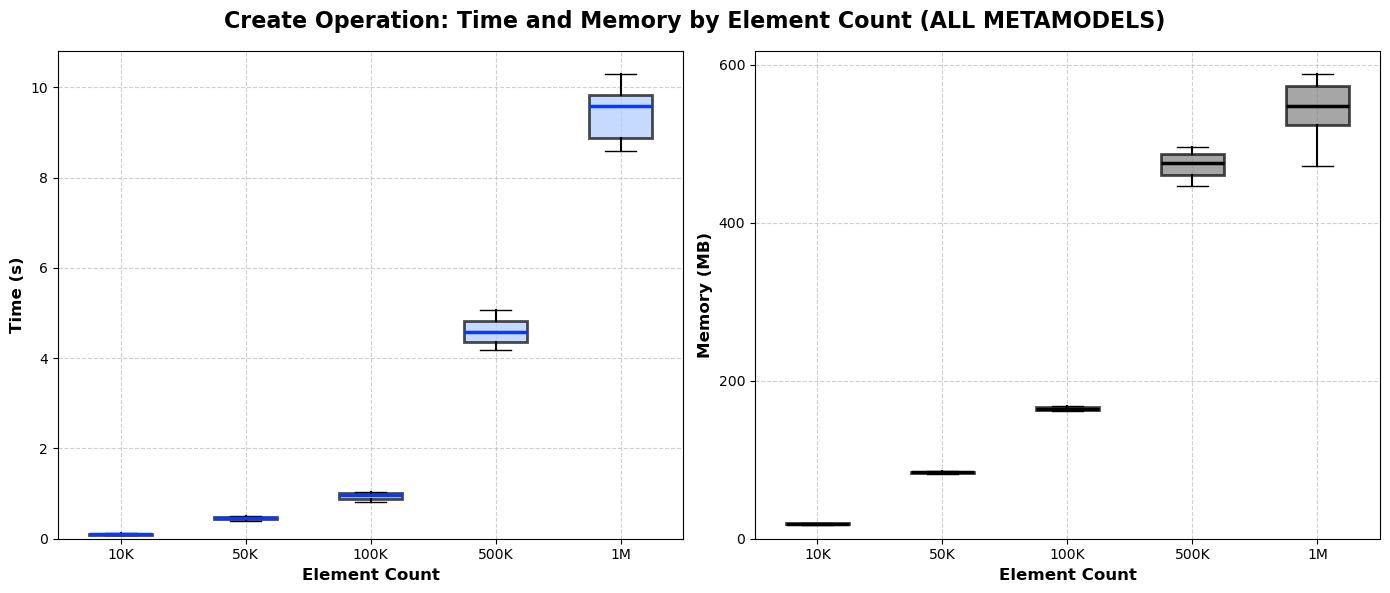

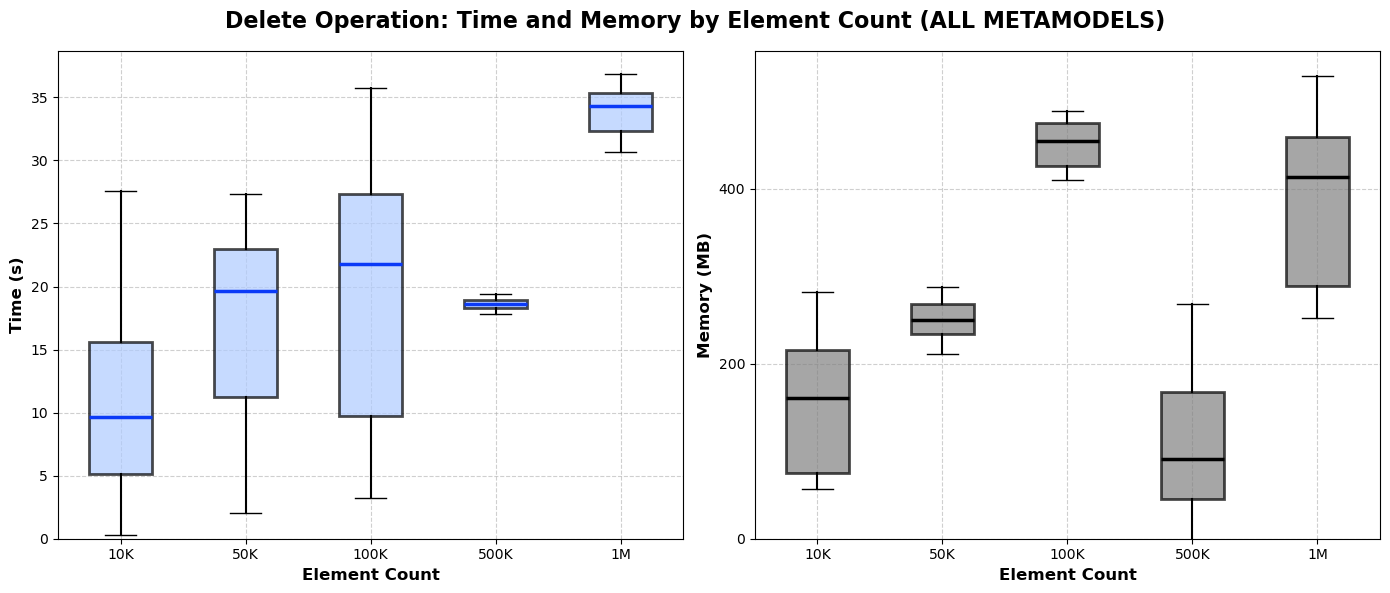

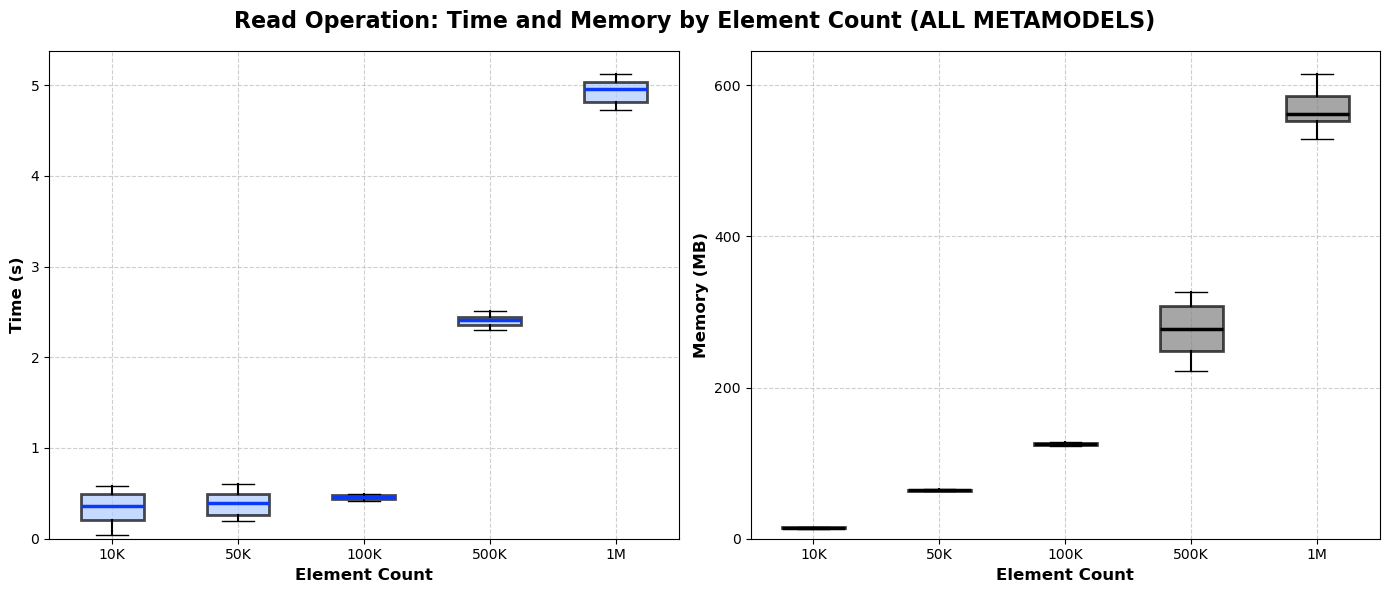

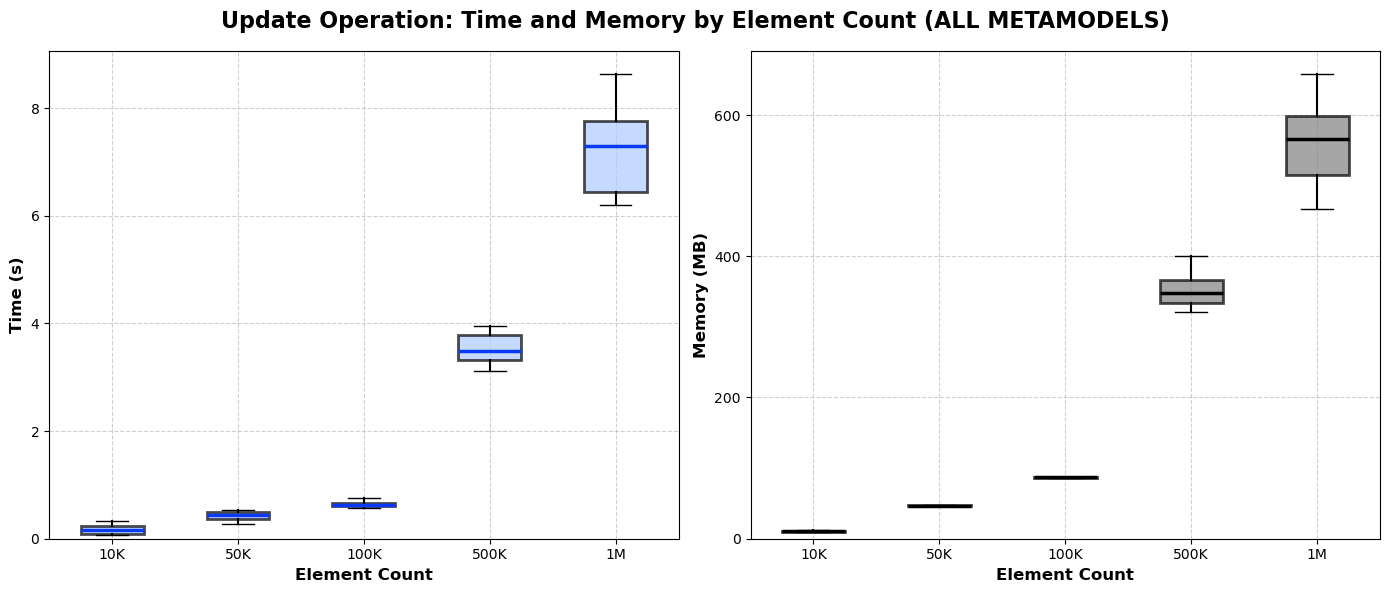

In [36]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE_FOLDER = "../results/RQ3GenModels"

group_col = "element_count"
pattern = re.compile(r"(.+)_run_\d+\.csv")


def plot_operation(df, op_name, metamodel_name):
    df["time"] = df["time"] / 1000  
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # -------- TIME --------
    df.boxplot(
        column="time",
        by=group_col,
        ax=axes[0],
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="#AFCBFF", color="black", linewidth=2, alpha=0.7),
        medianprops=dict(color="#0B3AF7", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.5),
    )

    axes[0].set_title("")
    axes[0].set_xlabel("Element Count", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Time (s)", fontsize=12, fontweight="bold")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].set_ylim(bottom=0)

    # -------- MEM --------
    df.boxplot(
        column="mem",
        by=group_col,
        ax=axes[1],
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="gray", color="black", linewidth=2, alpha=0.7),
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.5),
    )

    axes[1].set_xlabel("Element Count", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Memory (MB)", fontsize=12, fontweight="bold")

    axes[1].yaxis.set_major_locator(mticker.MultipleLocator(200 * 1024))
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x / 1024)}")
    )

    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].set_ylim(bottom=0)
    axes[1].set_title("")

    shorten_x_axis_labels(axes[0])
    shorten_x_axis_labels(axes[1])
    axes[0].set_ylim(bottom=0)
    axes[1].set_ylim(bottom=0)

    plt.suptitle(
        f"{op_name} Operation: Time and Memory by Element Count ({metamodel_name})",
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()

    plt.show()


# ---------------- main loop (MODIFIED ONLY PART) ----------------

operations = {}

for metamodel in os.listdir(BASE_FOLDER):
    folder_path = os.path.join(BASE_FOLDER, metamodel)

    if not os.path.isdir(folder_path):
        continue

    print(f"\n=== Loading {metamodel} ===")

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        match = pattern.match(file)
        if not match:
            continue

        op = match.group(1)

        df = pd.read_csv(os.path.join(folder_path, file))
        df["metamodel"] = metamodel  # kept for traceability (not used in plot)

        operations.setdefault(op, []).append(df)


for op, dfs in operations.items():
    full_df = pd.concat(dfs, ignore_index=True)

    # all metamodels combined
    plot_operation(full_df, op, "ALL METAMODELS")

## Read Operations

## Update Operations

## Delete Operations